In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q /content/drive/MyDrive/archive.zip -d /content/data

In [ ]:
import numpy as np
import pandas as pd
import os
import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers , models
import cv2

In [ ]:
import os

data_path = "/content/data"
print(os.listdir(data_path))

['Dataset']


In [ ]:
inner_path = os.path.join(data_path, "Dataset")
print(os.listdir(inner_path))

['Test', 'Train', 'Validation']


(256, 256, 3)


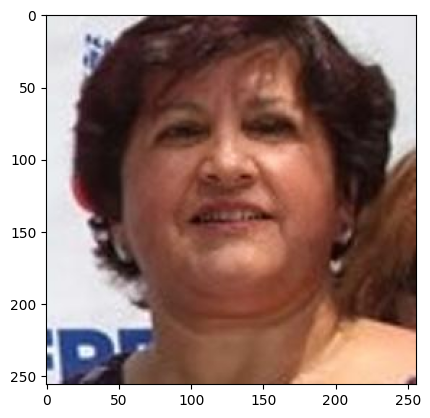

In [ ]:
# Providing path to dataset
base_dir ='/content/data/Dataset/Train'
image_path='/content/data/Dataset/Train/Fake/fake_1005.jpg'

# Reading the image
img=mpimg.imread(image_path)
print(img.shape)

#display image
plt.imshow(img)
plt.axis()
plt.show()

In [ ]:
img_size = 256
batch_size = 32


data_gen = ImageDataGenerator(
    zoom_range=0.2,
    fill_mode='nearest',
    validation_split=0.20, # 20% for Validation
    rescale=1./255
)



train_gen = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

valid_gen = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 112002 images belonging to 2 classes.
Found 28000 images belonging to 2 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models


# Create checkpoint directory
import os
checkpoint_dir = "/content/drive/MyDrive/cbam_checkpoints/"
os.makedirs(checkpoint_dir, exist_ok=True)



# Define CBAM Block

def cbam_block(input_feature, ratio=8):
    channel = input_feature.shape[-1]

    # ----- Channel Attention -----
    shared_dense_one = layers.Dense(channel // ratio,
                                    activation='relu',
                                    kernel_initializer='he_normal',
                                    use_bias=False)
    shared_dense_two = layers.Dense(channel,
                                    activation='sigmoid',
                                    kernel_initializer='he_normal',
                                    use_bias=False)

    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    avg_pool = layers.Reshape((1, 1, channel))(avg_pool)
    avg_pool = shared_dense_one(avg_pool)
    avg_pool = shared_dense_two(avg_pool)

    max_pool = layers.GlobalMaxPooling2D()(input_feature)
    max_pool = layers.Reshape((1, 1, channel))(max_pool)
    max_pool = shared_dense_one(max_pool)
    max_pool = shared_dense_two(max_pool)

    channel_attention = layers.Add()([avg_pool, max_pool])
    channel_attention = layers.Activation('sigmoid')(channel_attention)
    channel_refined = layers.Multiply()([input_feature, channel_attention])

    # ----- Spatial Attention -----
    avg_pool_spatial = layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(channel_refined)
    max_pool_spatial = layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(channel_refined)
    concat = layers.Concatenate(axis=-1)([avg_pool_spatial, max_pool_spatial])

    spatial_attention = layers.Conv2D(1, (7,7), padding='same', activation='sigmoid')(concat)
    refined_feature = layers.Multiply()([channel_refined, spatial_attention])

    return refined_feature


# Build Model

inputs = layers.Input(shape=(256,256,3))

x = layers.Conv2D(8, (3,3), activation='relu', padding='same')(inputs)
x = cbam_block(x)
x = layers.MaxPooling2D(2,2)(x)

x = layers.Conv2D(16, (3,3), activation='relu', padding='same')(x)
x = cbam_block(x)
x = layers.MaxPooling2D(2,2)(x)

x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = cbam_block(x)
x = layers.MaxPooling2D(2,2)(x)

x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = cbam_block(x)
x = layers.MaxPooling2D(2,2)(x)

x = layers.Flatten()(x)
x = layers.Dense(100, activation='relu')(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(2, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



# Model Checkpoint Callback (saveing epoch)

from tensorflow.keras.callbacks import ModelCheckpoint
import glob

checkpoint_path = os.path.join(checkpoint_dir, "epoch_{epoch:02d}_valacc_{val_accuracy:.3f}.weights.h5")

checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    save_freq='epoch',
    monitor='val_accuracy',
    mode='max',
    save_best_only=False,
    verbose=1
)



# Auto-resume training if previous checkpoint exists

checkpoints = glob.glob(os.path.join(checkpoint_dir, "*.weights.h5"))

if checkpoints:
    latest = max(checkpoints, key=os.path.getctime)
    print(f" Found checkpoint: {latest}")
    model.load_weights(latest)
    print(" Loaded weights. Training will resume.")
else:
    print(" No previous checkpoint found. Training starts fresh.")


# Train the model (with checkpoint saving)

history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=5,
    callbacks=[checkpoint_callback]
)


 No previous checkpoint found. Training starts fresh.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.6823 - loss: 0.5713
Epoch 1: saving model to /content/drive/MyDrive/cbam_checkpoints/epoch_01_valacc_0.803.weights.h5
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 2061s 583ms/step - accuracy: 0.6823 - loss: 0.5713 - val_accuracy: 0.8034 - val_loss: 0.4275
Epoch 2/5
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.8226 - loss: 0.3855
Epoch 2: saving model to /content/drive/MyDrive/cbam_checkpoints/epoch_02_valacc_0.888.weights.h5
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 1996s 570ms/step - accuracy: 0.8226 - loss: 0.3855 - val_accuracy: 0.8884 - val_loss: 0.2638
Epoch 3/5
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.8978 - loss: 0.2443
Epoch 3: saving model to /content/drive/MyDrive/cbam_checkpoints/epoch_03_valacc_0.916.weights.h5
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 1998s 571ms/step - accuracy: 0.8978 - loss: 0.2443 - val_accuracy: 0.9165 - val_loss: 0.2002
Epoch 4/5
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 

In [ ]:
# ============================================
# Load Test Set
# ============================================

test_dir = "/content/data/Dataset/Test"

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# ============================================
# Predict on Test Set
# ============================================

test_gen.reset()

Y_prob = model.predict(test_gen)
Y_pred = np.argmax(Y_prob, axis=1)
Y_true = test_gen.classes

# Ensure class names follow correct index order
class_indices = test_gen.class_indices
class_names = [k for k,v in sorted(class_indices.items(), key=lambda x: x[1])]

# ============================================
# Classification Report
# ============================================

from sklearn.metrics import classification_report

print("\n--- TEST SET CLASSIFICATION REPORT ---\n")
print(classification_report(Y_true, Y_pred, target_names=class_names))


Found 10905 images belonging to 2 classes.
341/341 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step

--- TEST SET CLASSIFICATION REPORT ---

              precision    recall  f1-score   support

        Fake       0.79      0.91      0.85      5492
        Real       0.89      0.76      0.82      5413

    accuracy                           0.83     10905
   macro avg       0.84      0.83      0.83     10905
weighted avg       0.84      0.83      0.83     10905



341/341 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step


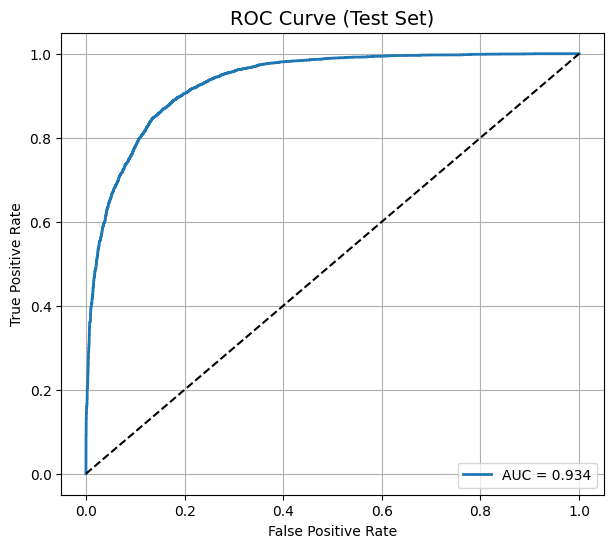

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# ============================
# ROC-AUC on TEST SET
# ============================

# Reset test generator to avoid index mix-up
test_gen.reset()

# Predictions (probabilities)
Y_prob = model.predict(test_gen)

# True labels
Y_true = test_gen.classes

# If softmax with 2 outputs → use probability of class 1
if Y_prob.shape[1] == 2:
    Y_prob = Y_prob[:, 1]
else:
    Y_prob = Y_prob.ravel()

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(Y_true, Y_prob)
auc_score = roc_auc_score(Y_true, Y_prob)

# Plot ROC curve
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.title('ROC Curve (Test Set)', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


341/341 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step


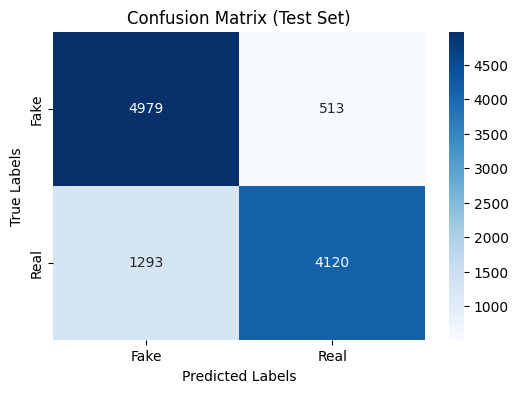

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ============================
# Confusion Matrix on TEST SET
# ============================

# Reset generator
test_gen.reset()

# Predictions
Y_prob = model.predict(test_gen)
Y_pred = np.argmax(Y_prob, axis=1)
Y_true = test_gen.classes

# Compute confusion matrix
cm = confusion_matrix(Y_true, Y_pred)

# Ensure class names match index order
class_indices = test_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix (Test Set)")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


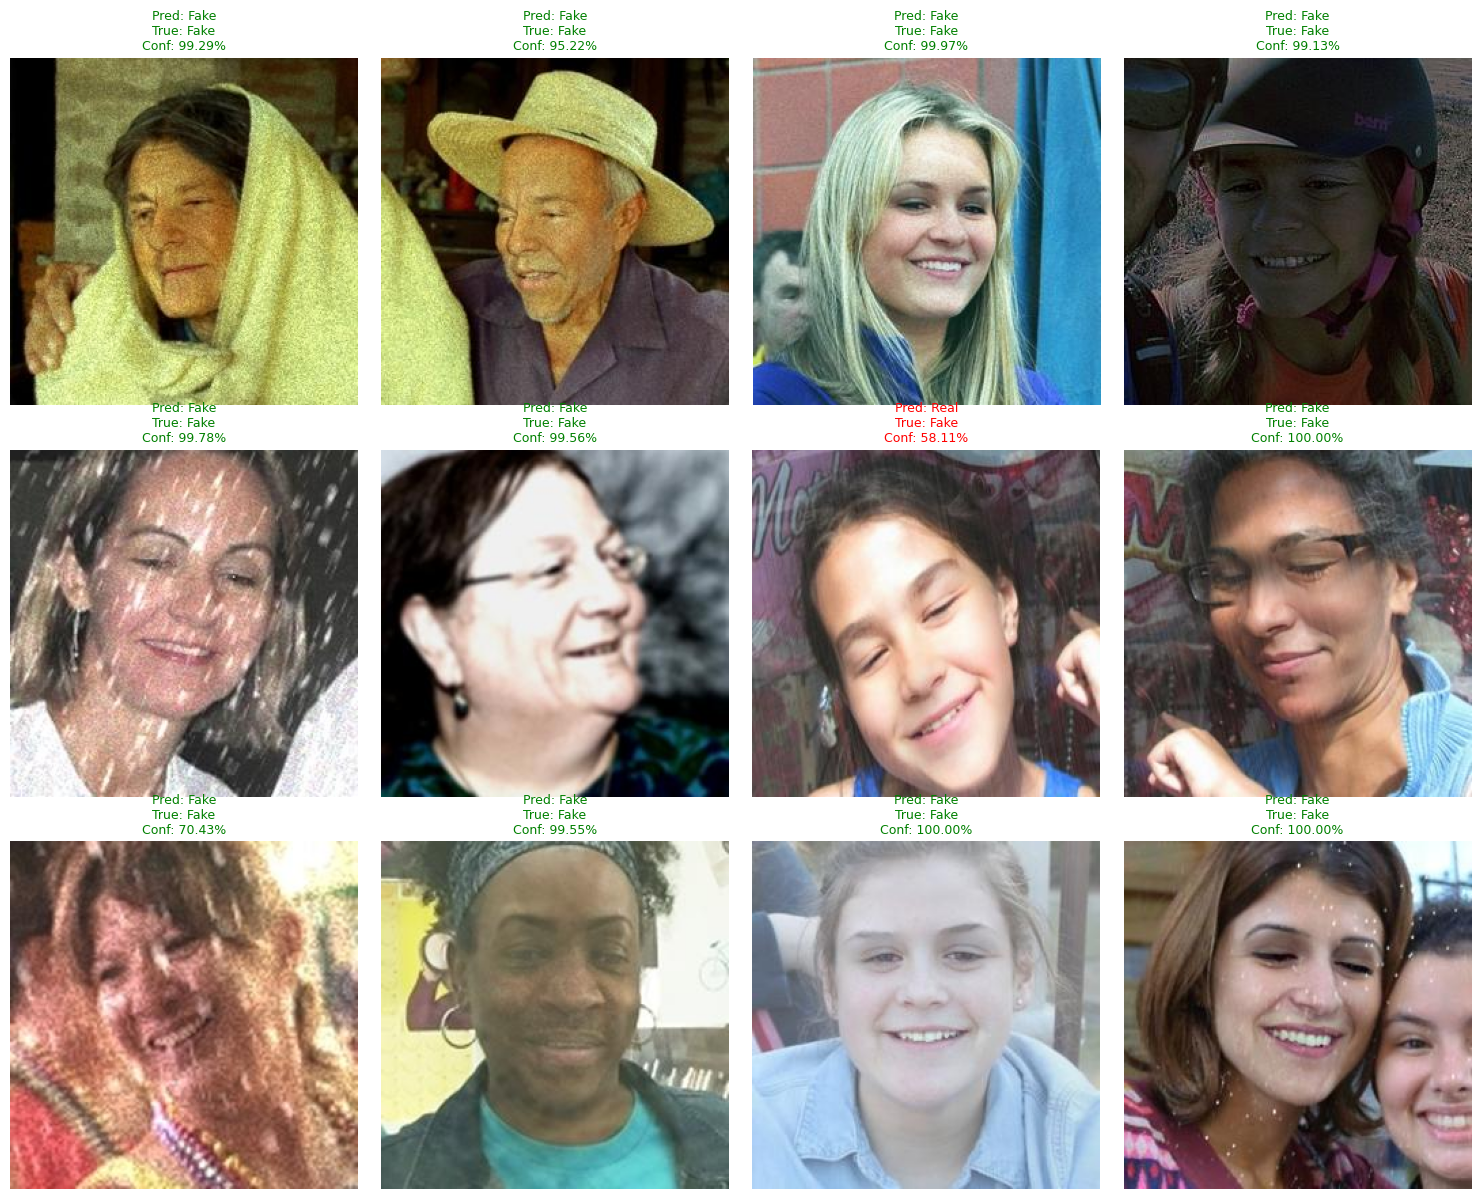

In [ ]:
# to showing some sample test images

import matplotlib.pyplot as plt
import numpy as np

# How many test images to display
num_images_to_show = 12

# Reset test generator
test_gen.reset()

# Take one batch of test images
x_test_batch, y_test_batch = next(test_gen)

# True labels (integer)
true_labels = np.argmax(y_test_batch, axis=1)

# Predict on batch
pred_probs = model.predict(x_test_batch)
pred_labels = np.argmax(pred_probs, axis=1)

# Confidence score (max probability)
confidence_scores = np.max(pred_probs, axis=1)

# Class names in correct order
class_indices = test_gen.class_indices
class_names = [k for k,v in sorted(class_indices.items(), key=lambda x: x[1])]

# Plot predictions
plt.figure(figsize=(15, 12))
for i in range(num_images_to_show):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test_batch[i])

    pred = class_names[pred_labels[i]]
    true = class_names[true_labels[i]]
    conf = confidence_scores[i] * 100  # convert to percentage

    # Green = correct, Red = wrong
    color = "green" if pred == true else "red"

    plt.title(f"Pred: {pred}\nTrue: {true}\nConf: {conf:.2f}%",
              color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# grad -CAM

import tensorflow as tf
import numpy as np
import cv2

def get_gradcam_heatmap(model, image_array, last_conv_layer_name, pred_index=None):
    # Create a model mapping input → (conv outputs, predictions)
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_array)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        pred_output = predictions[:, pred_index]

    # Compute gradients
    grads = tape.gradient(pred_output, conv_outputs)

    # Vector of mean gradient for each channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weighting conv maps by importance
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

    return heatmap.numpy()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 256, 256, 3))
  warnings.warn(msg)


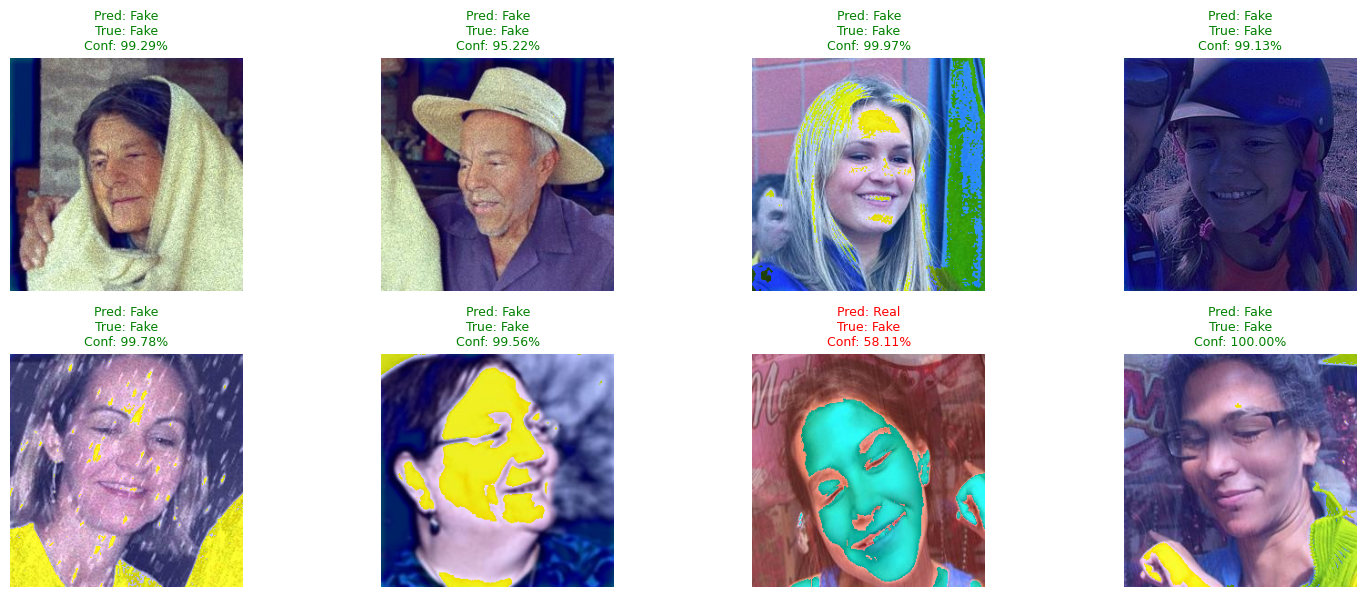

In [ ]:
import matplotlib.pyplot as plt

last_conv_layer = "conv2d_3"   # change if summary shows different name

num_images_to_show = 8

# reset test generator
test_gen.reset()

x_batch, y_batch = next(test_gen)

pred_probs = model.predict(x_batch)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = np.argmax(y_batch, axis=1)

confidence_scores = np.max(pred_probs, axis=1)

# Class names in correct order
class_indices = test_gen.class_indices
class_names = [k for k,v in sorted(class_indices.items(), key=lambda x: x[1])]

plt.figure(figsize=(15, 12))

for i in range(num_images_to_show):

    img = x_batch[i]
    img_expanded = np.expand_dims(img, axis=0)

    # --------- Generate Grad-CAM Heatmap ----------
    heatmap = get_gradcam_heatmap(model, img_expanded, last_conv_layer)

    # Resize heatmap to image size
    heatmap = cv2.resize(heatmap, (256, 256))
    heatmap = np.uint8(255 * heatmap)

    # Apply colormap
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Overlay heatmap with original image
    superimposed_img = heatmap_color * 0.4 + (img * 255)

    pred = class_names[pred_labels[i]]
    true = class_names[true_labels[i]]
    conf = confidence_scores[i] * 100

    color = "green" if pred == true else "red"

    plt.subplot(4, 4, i + 1)
    plt.imshow(superimposed_img.astype("uint8"))
    plt.title(f"Pred: {pred}\nTrue: {true}\nConf: {conf:.2f}%", color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import f1_score

# Reset test generator
test_gen.reset()

# Predict on test set
Y_prob = model.predict(test_gen)
Y_pred = np.argmax(Y_prob, axis=1)
Y_true = test_gen.classes

# F1 score (macro average)
f1 = f1_score(Y_true, Y_pred, average='macro')

print("F1 Score (Macro):", f1)


341/341 ━━━━━━━━━━━━━━━━━━━━ 21s 63ms/step
F1 Score (Macro): 0.8333538724248599


341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step


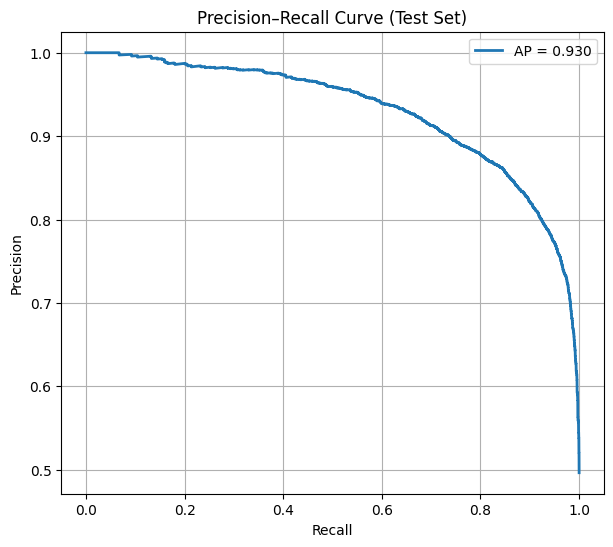

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Reset test generator
test_gen.reset()

# Predict probabilities
Y_prob = model.predict(test_gen)

# Extract probability for positive class
# (Assuming class 1 = Real, check test_gen.class_indices)
if Y_prob.shape[1] == 2:
    Y_prob_pos = Y_prob[:, 1]
else:
    Y_prob_pos = Y_prob.ravel()

# True labels
Y_true = test_gen.classes

# Compute PR curve
precision, recall, thresholds = precision_recall_curve(Y_true, Y_prob_pos)

# Average Precision Score (area under PR curve)
ap = average_precision_score(Y_true, Y_prob_pos)

# Plot PR Curve
plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"AP = {ap:.3f}", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Test Set)")
plt.legend()
plt.grid(True)
plt.show()
